# Eigenmodes of the Score Hamiltonian

This demo offers a simple illustration of the spectral structure of the Score Hamiltonian and its adiabatic interpretation for the paper *The Score Hamiltonian: Mapping Diffusion Models to Adiabatic Transport.*

In particular, the notebook constructs the **Score Hamiltonian** $\widehat{H}_\theta$ from a score network on the Two Moons dataset, diagonalises it, and visualises its eigenfunctions and eigenvalues. This visualizes the sense in which the Score Hamiltonian is a general-purpose spectral tool for understanding diffusion models which applies to arbitrary densities learnable through score-based diffusion models.


## Setup: Score Network and Hamiltonian Construction

In [4]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
from sklearn.datasets import make_moons
from tqdm.auto import tqdm

plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.dpi': 300,
    'font.family': 'serif',
    'image.cmap': 'RdBu_r',
})

# ── Dataset ────────────────────────────────────────────────────────────────
X_data, _ = make_moons(n_samples=15000, noise=0.07)
X_data = (X_data - X_data.mean(axis=0)) / X_data.std(axis=0)

from src.models import ScoreNet2D as ScoreNet

model = ScoreNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

sigma = 0.20          # terminal noise scale
X_tensor = torch.tensor(X_data, dtype=torch.float32)

model.train()
for epoch in tqdm(range(1200), desc='Training score network'):
    noise = torch.randn_like(X_tensor) * sigma
    x_noisy = X_tensor + noise
    score_pred = model(x_noisy)
    target = -noise / (sigma**2)
    loss = torch.mean(torch.sum((score_pred - target)**2, dim=1))
    optimizer.zero_grad(); loss.backward(); optimizer.step()

# ── Evaluate score on grid ─────────────────────────────────────────────────
model.eval()
N = 120
limit = 2.5
x_lin = np.linspace(-limit, limit, N)
y_lin = np.linspace(-limit, limit, N)
dx = x_lin[1] - x_lin[0]
xx, yy = np.meshgrid(x_lin, y_lin)

grid_pts = np.c_[xx.ravel(), yy.ravel()]
with torch.no_grad():
    S_eval = model(torch.tensor(grid_pts, dtype=torch.float32))
S_x = S_eval[:, 0].numpy().reshape(N, N)
S_y = S_eval[:, 1].numpy().reshape(N, N)

# ── Score Hamiltonian  H = -1/2 Delta + V,  V = (1/4) div S + (1/8)|S|^2 ──
div_S     = np.gradient(S_x, dx, axis=1) + np.gradient(S_y, dx, axis=0)
norm_S_sq = S_x**2 + S_y**2
V_score   = 0.25 * div_S + 0.125 * norm_S_sq

# Hard-wall boundary conditions
V_score[:2, :] = 500; V_score[-2:, :] = 500
V_score[:, :2] = 500; V_score[:, -2:] = 500

ex = np.ones(N)
D2 = sp.spdiags([ex, -2*ex, ex], [-1, 0, 1], N, N) / (dx**2)
Laplacian = sp.kronsum(D2, D2)
H = -0.5 * Laplacian + sp.diags(V_score.ravel())

# ── Diagonalise ────────────────────────────────────────────────────────────
K = 8
vals, vecs = eigsh(H, k=K, which='SA')
vals = vals - vals[0]   # shift so E0 = 0
for i in range(K):
    vecs[:, i] /= np.max(np.abs(vecs[:, i]))

print(f'Spectral gap  Delta_E = E1 - E0 = {vals[1]:.4f}')
print(f'Eigenvalues:  {np.round(vals, 4)}')


Training score network:   0%|          | 0/1200 [00:00<?, ?it/s]

Spectral gap  Delta_E = E1 - E0 = 0.1651
Eigenvalues:  [0.     0.1651 0.5263 0.5719 1.0964 1.4423 2.1908 2.395 ]


## Eigenfunctions and Eigenvalues of the Score Hamiltonian

The **Score Hamiltonian** associated with a learned score $S_\theta \approx \nabla \log \rho$ is (in physical units $-\frac{1}{2}\nabla^2$)
$$
\widehat{H}_\theta = -\tfrac{1}{2}\nabla^2 + V_\theta(x),
\qquad
V_\theta = \tfrac{1}{4}\nabla \cdot S_\theta + \tfrac{1}{8}|S_\theta|^2.
$$
The potential $V_\theta$ is the (negative) Bohm quantum potential of the learned density amplitude $\sqrt{\rho_\theta}$.

Its eigenstates $\{\psi_n\}$ and eigenvalues $\{E_n\}$ satisfy $\widehat{H}_\theta\,\psi_n = E_n\,\psi_n$ (shifted so $E_0 = 0$):

| State | Physical meaning |
|---|---|
| $\psi_0$ (ground state) | $|\psi_0|^2 \propto \rho_\theta$: the learned data density |
| $\psi_1$ (first excited) | Principal separation mode; its nodal line bisects the two moons -- this is the topological bottleneck determining the spectral gap. |
| $\psi_2, \psi_3, \ldots$ | Higher-frequency deformations |

The **spectral gap** $\Delta E = E_1 - E_0$ equals the inverse Poincaré constant of $\rho_\theta$. It sets the fundamental speed limit of adiabatic sampling: a smaller gap means harder transport (Theorem 2 of the paper).


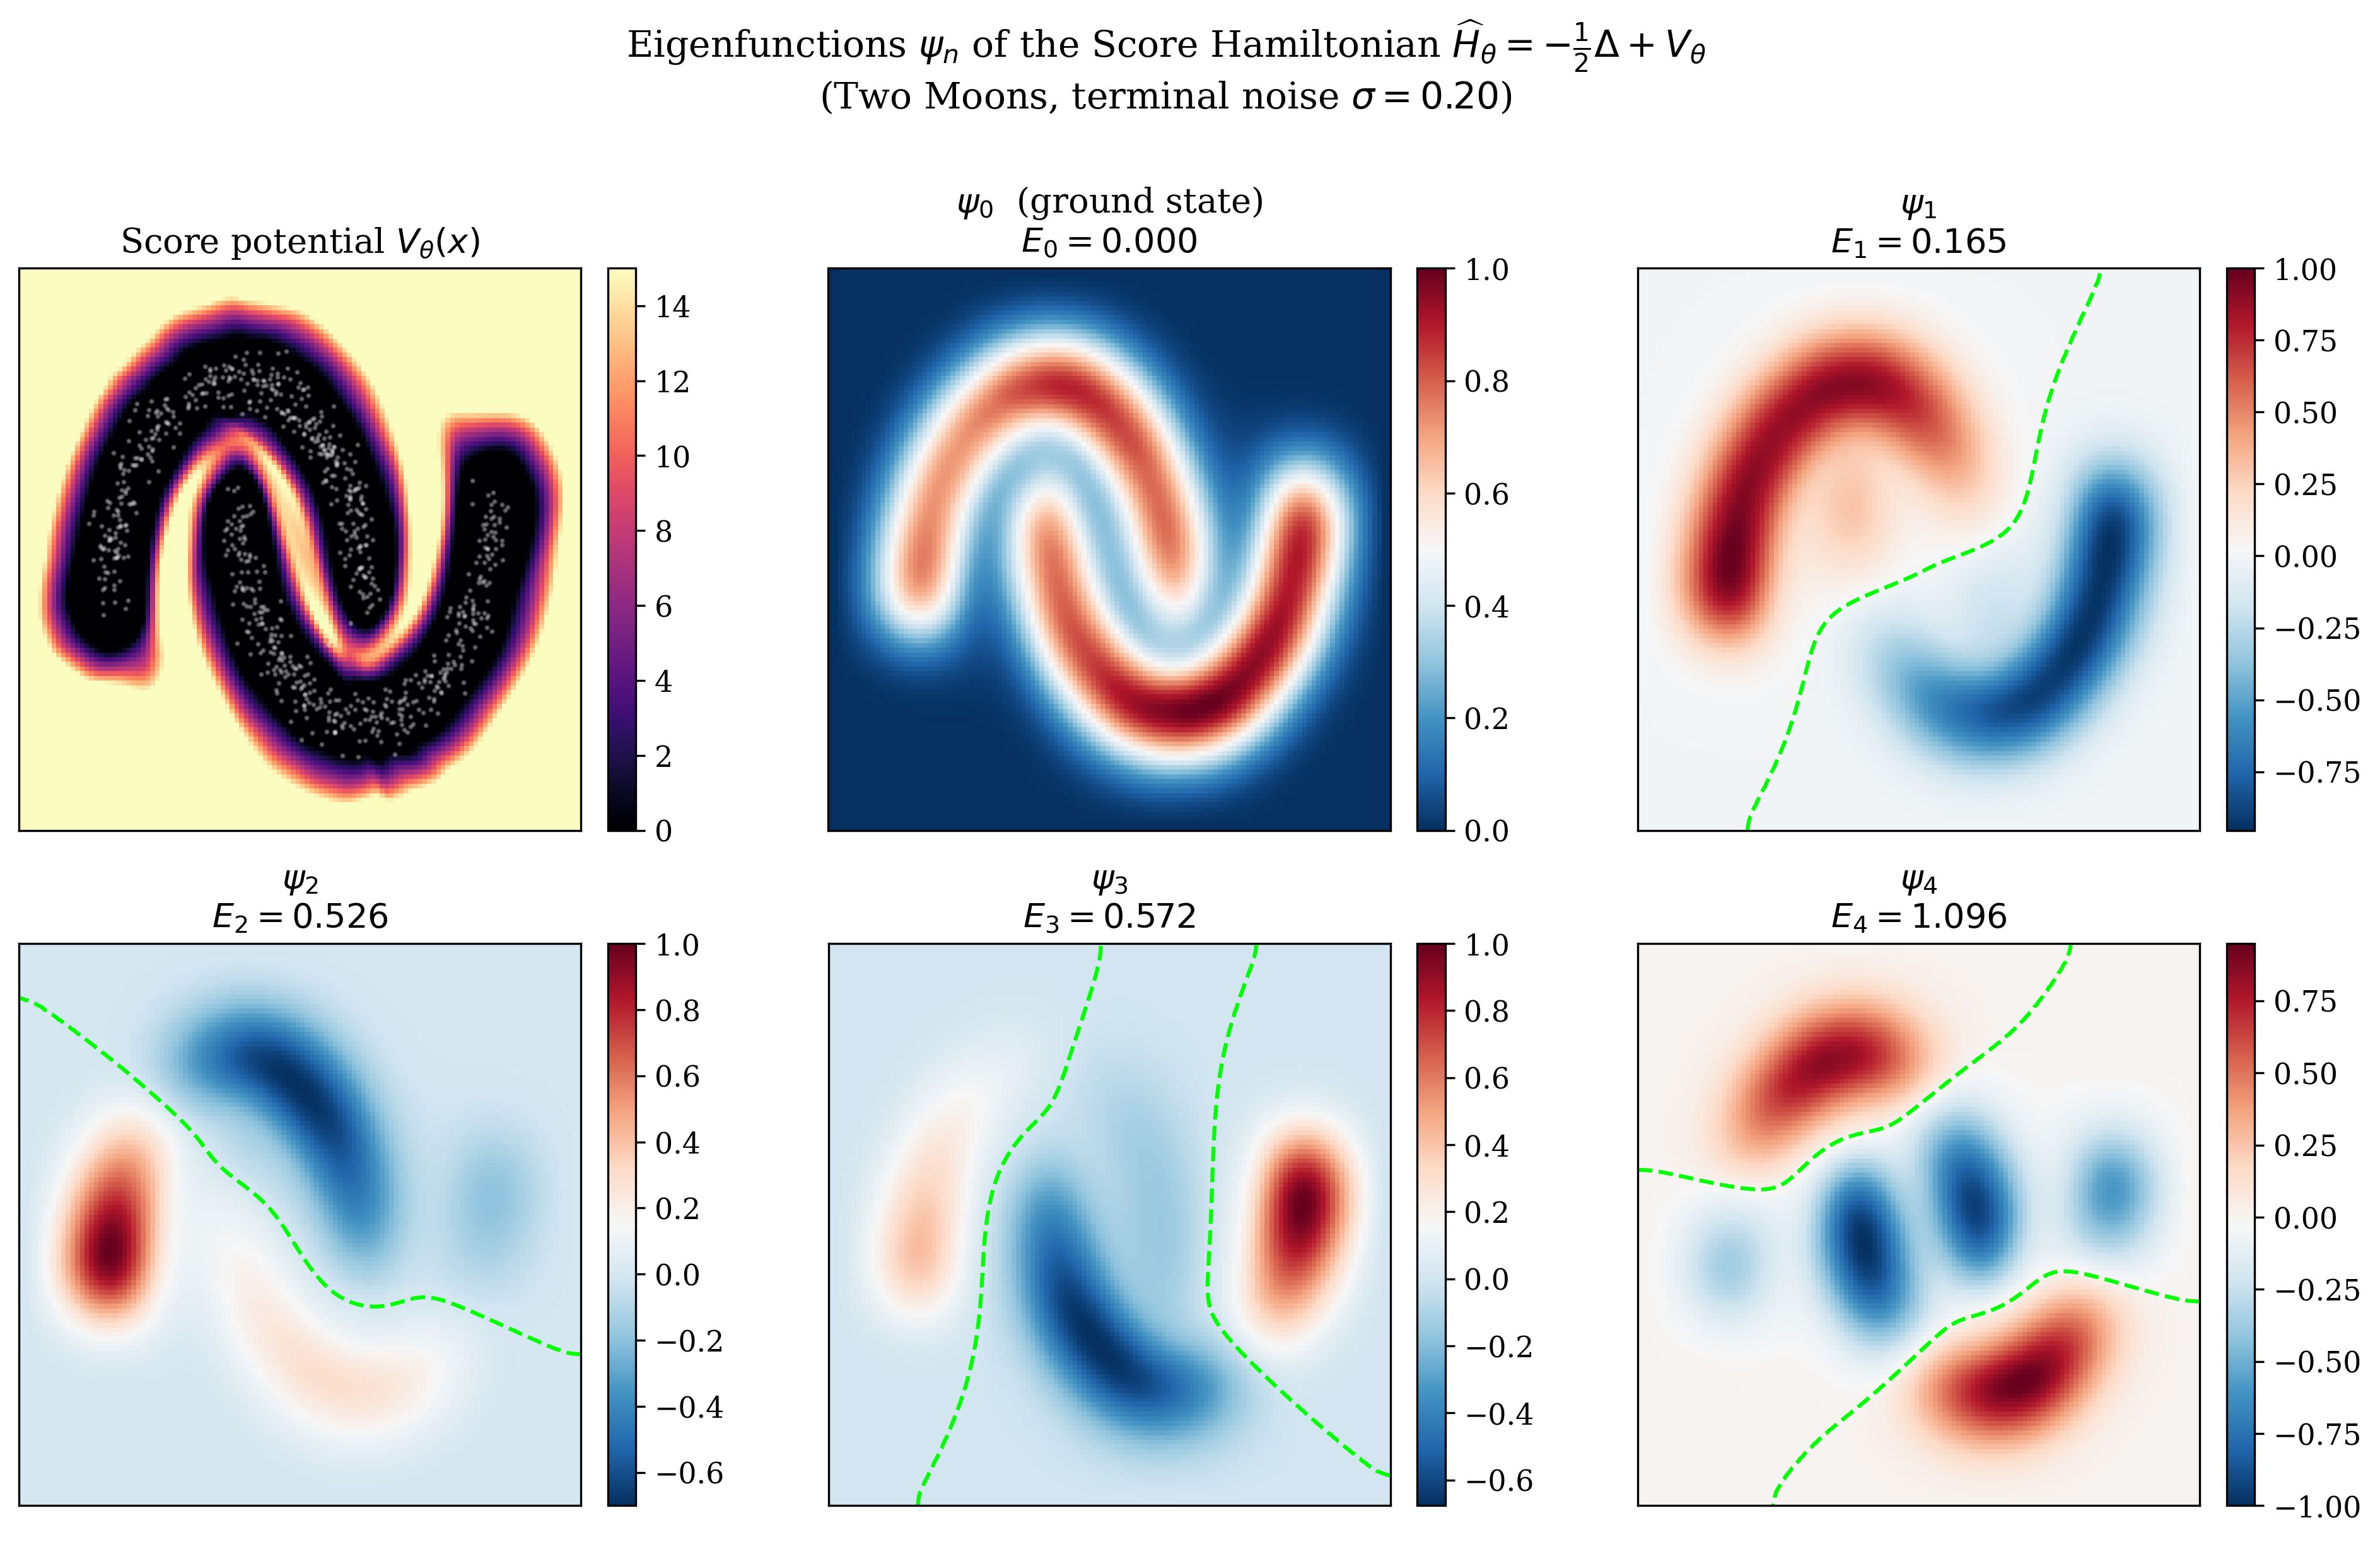

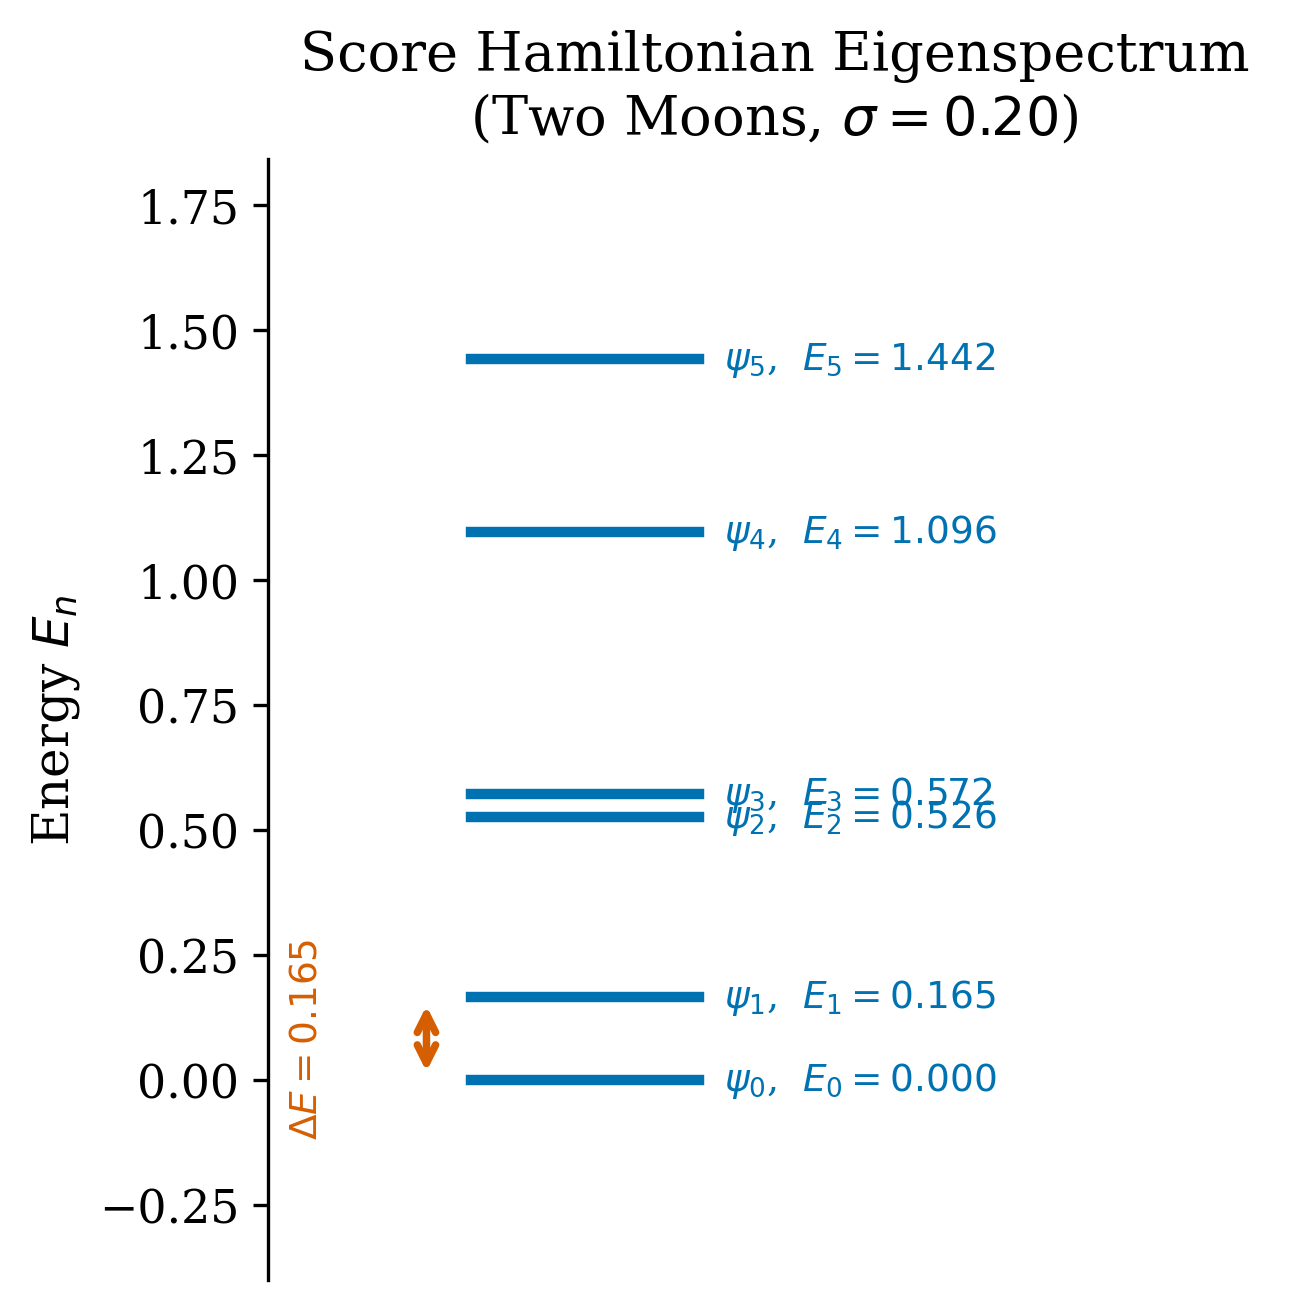

In [5]:
# ── Eigenfunction grid (2 rows x 3 cols: potential + psi_0...psi_4) ────────
n_show = 5          # number of eigenstates to display
ext    = [-limit, limit, -limit, limit]

fig1, axes1 = plt.subplots(2, 3, figsize=(13, 8))
fig1.suptitle(
    r'Eigenfunctions $\psi_n$ of the Score Hamiltonian '
    r'$\widehat{H}_\theta = -\frac{1}{2}\Delta + V_\theta$'
    '\n(Two Moons, terminal noise $\sigma = 0.20$)',
    fontsize=14, y=1.01,
)

for idx, ax in enumerate(axes1.flatten()):
    if idx == 0:
        im = ax.imshow(np.clip(V_score, 0, 15), extent=ext, origin='lower', cmap='magma')
        ax.scatter(X_data[:800, 0], X_data[:800, 1], s=1, color='white', alpha=0.25)
        ax.set_title(r'Score potential $V_\theta(x)$')
        fig1.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        n = idx - 1
        psi = vecs[:, n].reshape(N, N)
        im  = ax.imshow(psi, extent=ext, origin='lower')
        label  = r'$\psi_0$  (ground state)' if n == 0 else rf'$\psi_{n}$'
        ax.set_title(f'{label}\n$E_{n} = {vals[n]:.3f}$')
        if n > 0:
            ax.contour(xx, yy, psi, levels=[0], colors='lime', linewidths=1.5, linestyles='--')
        fig1.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('eigenmodes_score_hamiltonian.pdf', bbox_inches='tight')
plt.show()

# ── Discrete eigenspectrum (energy ladder, analogous to hydrogen spectrum) ──
C_SCORE = '#0072B2'
C_GAP   = '#D55E00'

fig2, ax2 = plt.subplots(figsize=(4.5, 4.5))

x0 = 0.5
for n in range(n_show + 1):
    E = vals[n]
    ax2.plot([x0 - 0.18, x0 + 0.18], [E, E], color=C_SCORE, lw=2.5)
    ax2.text(x0 + 0.22, E, rf'$\psi_{n}$,  $E_{n}={E:.3f}$',
             va='center', fontsize=9, color=C_SCORE)

# Annotate spectral gap
ax2.annotate('', xy=(x0 - 0.25, vals[1]), xytext=(x0 - 0.25, vals[0]),
             arrowprops=dict(arrowstyle='<->', color=C_GAP, lw=1.8))
ax2.text(x0 - 0.44, (vals[0] + vals[1]) / 2,
         rf'$\Delta E = {vals[1]:.3f}$', color=C_GAP,
         ha='center', va='center', fontsize=9, rotation=90)

ax2.set_xlim(0, 1.6)
ax2.set_ylim(vals[0] - 0.4, vals[n_show] + 0.4)
ax2.set_xticks([])
ax2.set_ylabel('Energy $E_n$')
ax2.set_title('Score Hamiltonian Eigenspectrum\n(Two Moons, $\sigma = 0.20$)')
ax2.spines[['top', 'right', 'bottom']].set_visible(False)
plt.tight_layout()
plt.savefig('eigenspectrum_score_hamiltonian.pdf', bbox_inches='tight')
plt.show()


## Adiabatic Evolution of Score Hamiltonian Eigenstates

As the diffusion model anneals the noise scale $\sigma_t$ from large (blurred prior) toward small (near-data), the Score Hamiltonian $\widehat{H}_\theta(t)$ evolves adiabatically.

- For large $\sigma$ (high noise): the data distribution is a single unimodal blob. The ground state $\psi_0$ is a smooth bump; the spectral gap $\Delta E$ is large — easy transport.

- For intermediate $\sigma$: the two moons begin to crystallise. The first excited state $\psi_1$ develops a nodal line separating the two emerging modes.

- For small $\sigma$ (near data): the two moons are sharply resolved. The spectral gap $\Delta E \to 0$ as the topological bottleneck forms -- the closing gap signals that crossing between modes becomes exponentially slow.

The adiabatic theorem (Thm.\ 1 of the paper) bounds the tracking error as
$$
\sqrt{\chi^2(\mu_\tau \| \rho_{t_\tau})} \lesssim \frac{|\dot{t}| \cdot \|\partial_t \log\rho_t\|_{L^2}}{\Delta(t)}.
$$
When $\Delta(t) \to 0$, a slower annealing schedule $\dot{t}$ is required to remain in the ground state.


Diagonalising at each sigma:   0%|          | 0/4 [00:00<?, ?it/s]

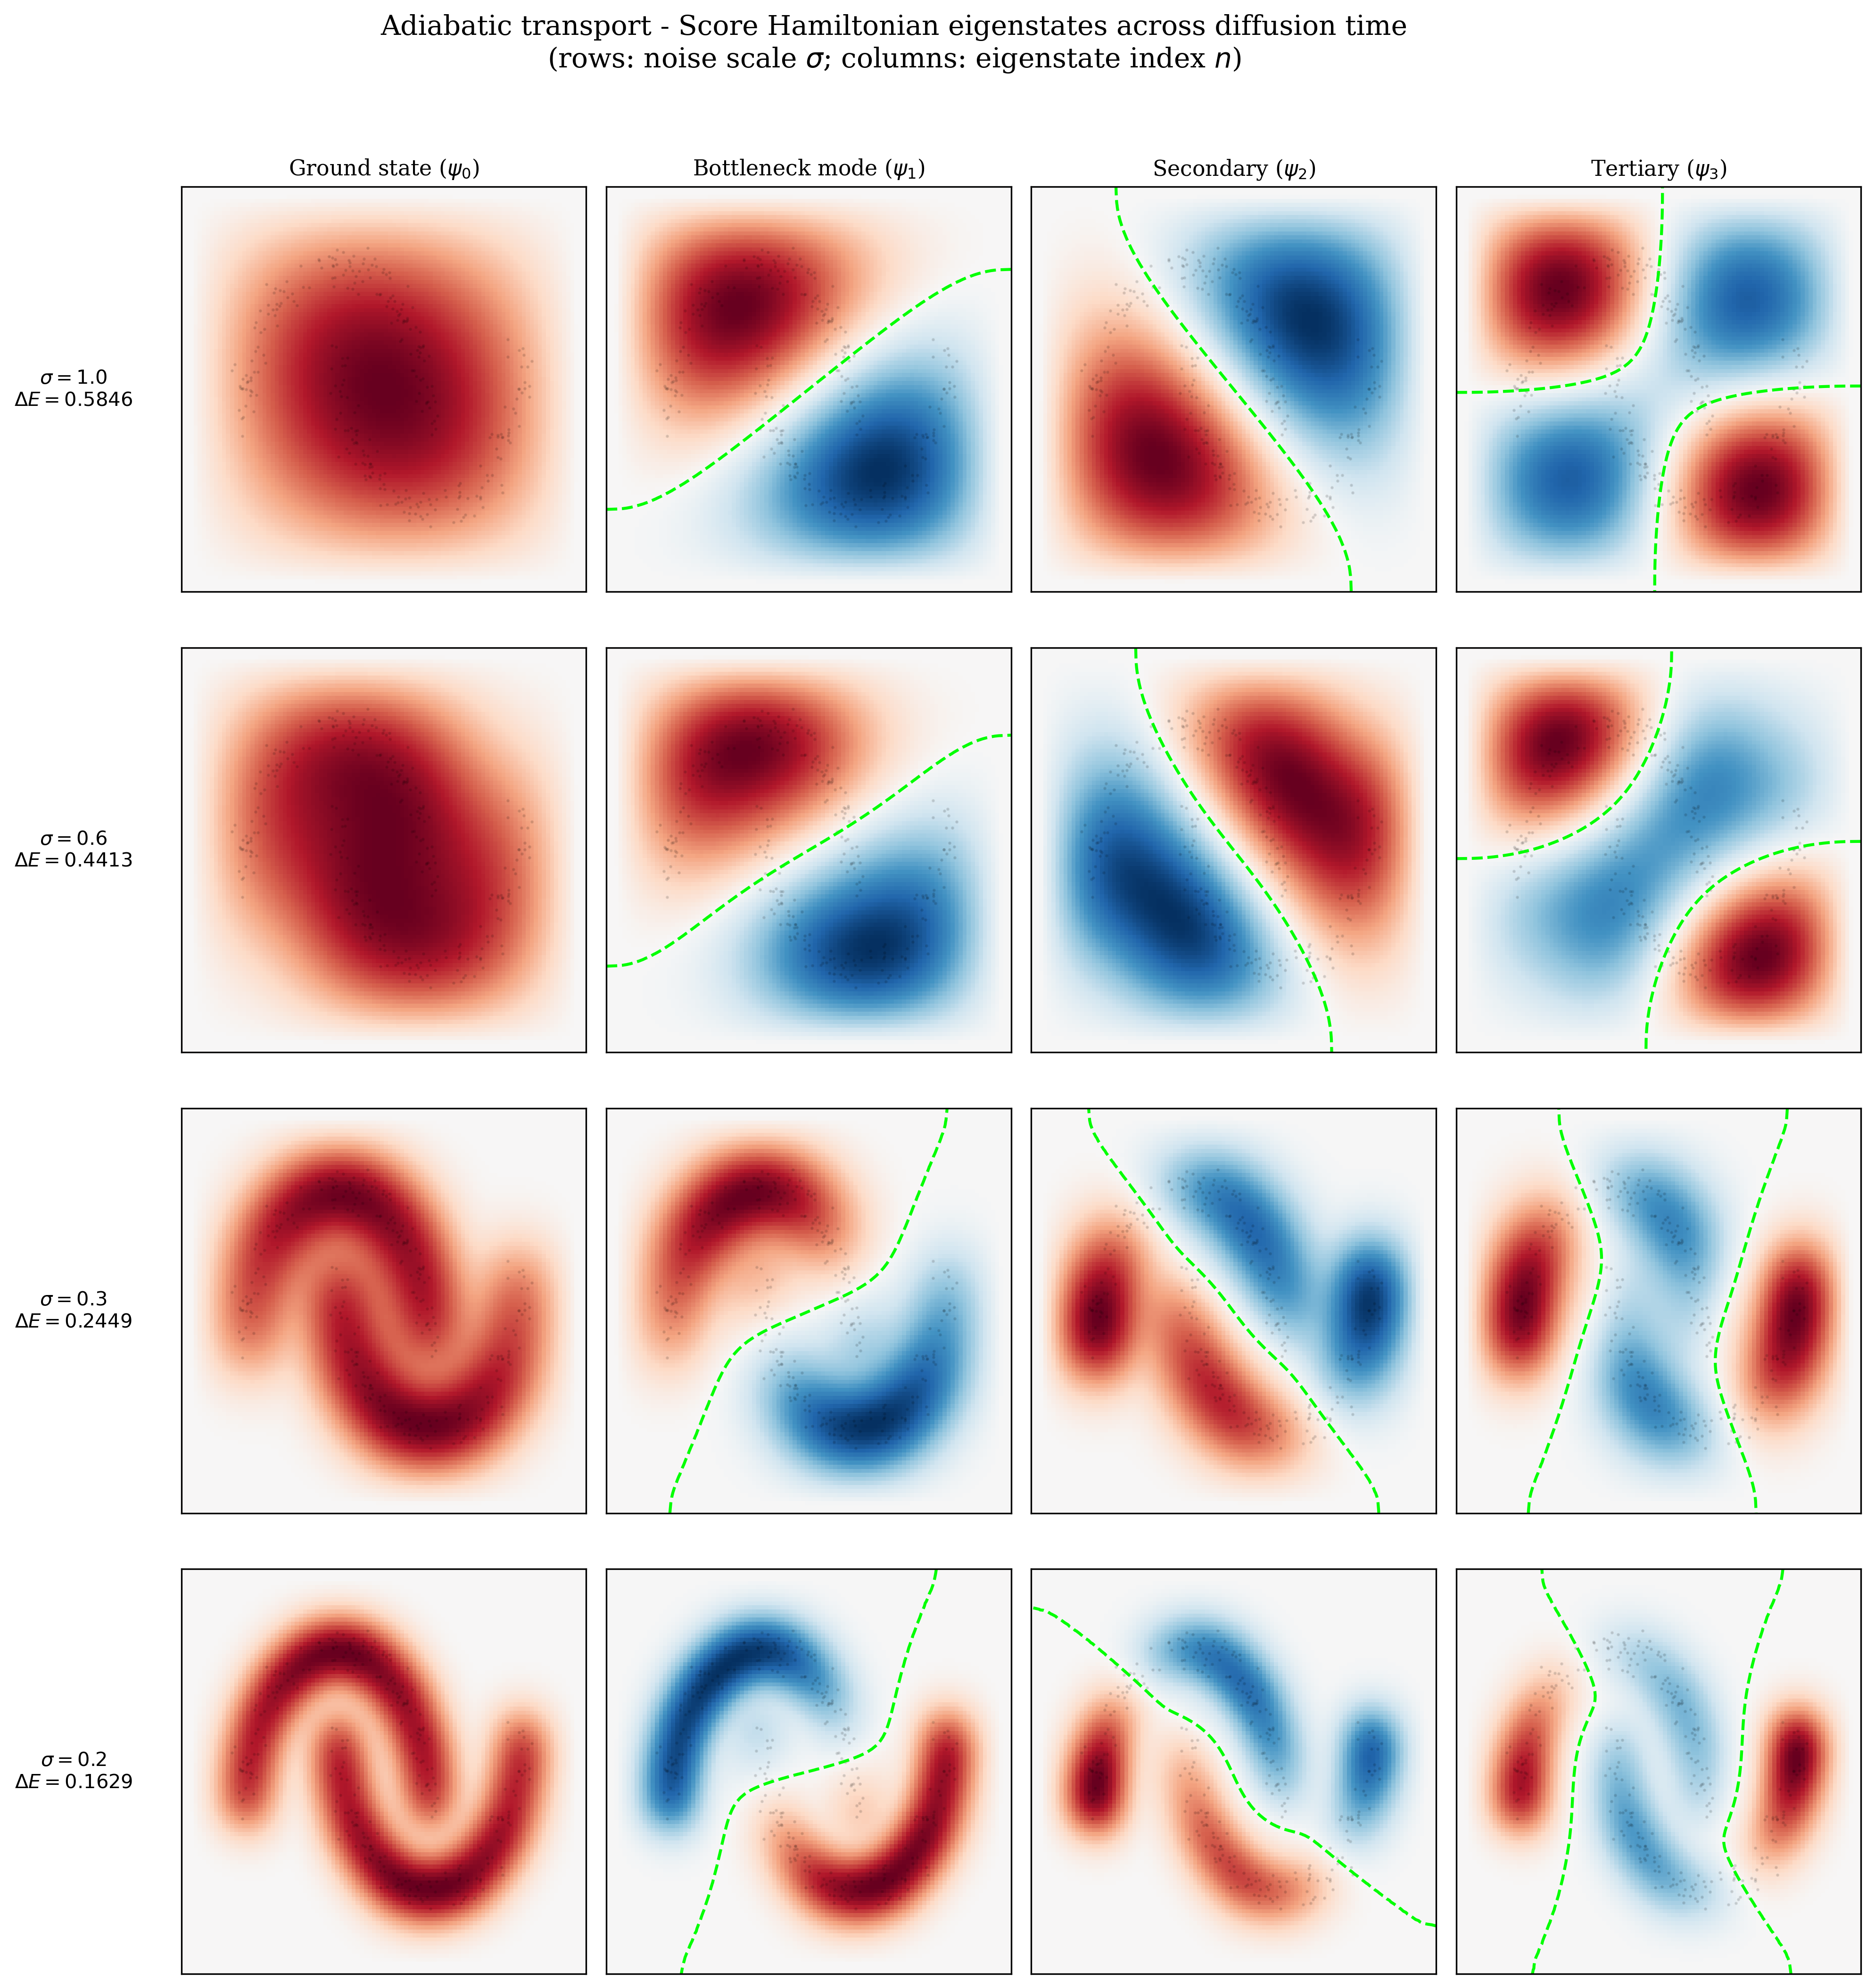

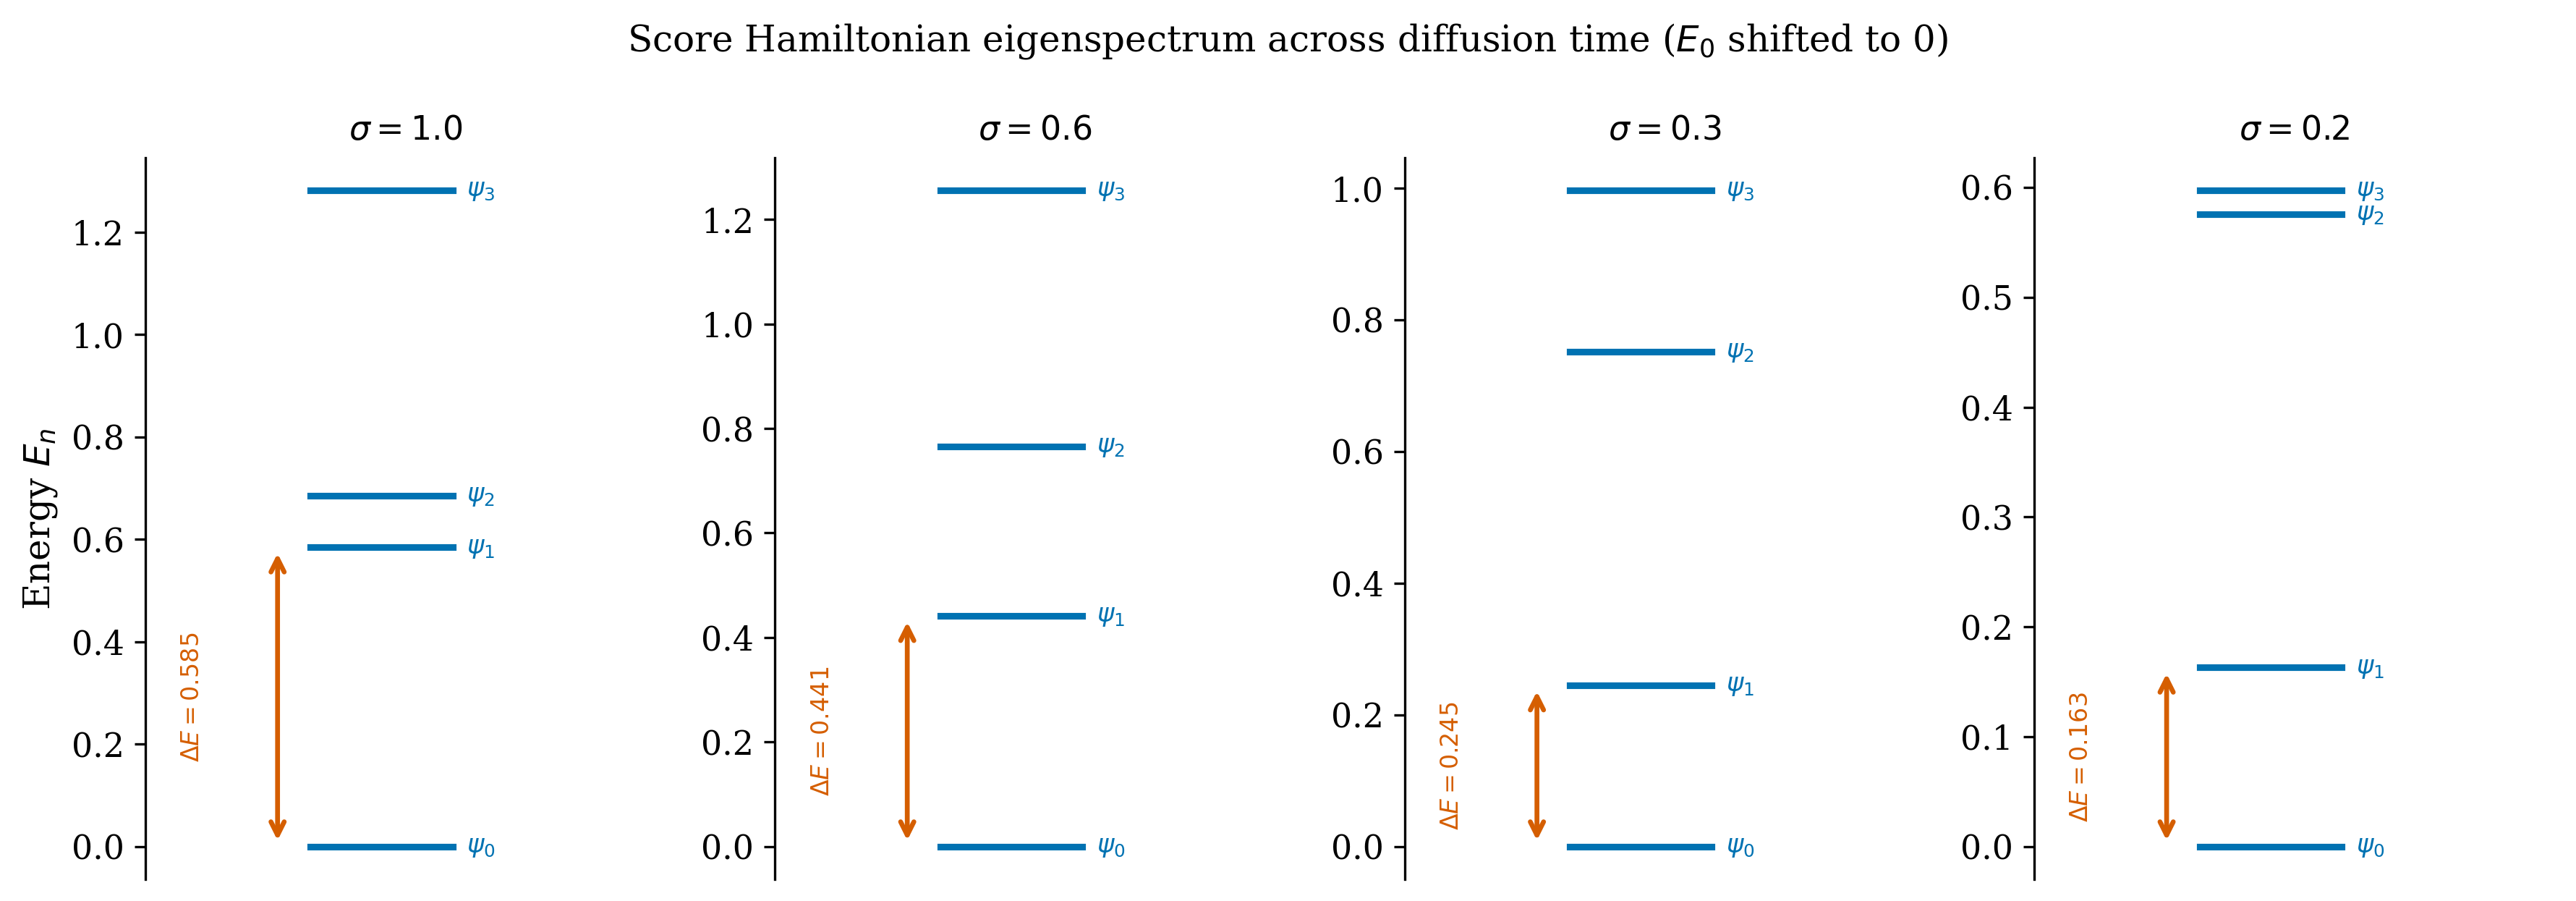

In [6]:
import torch.nn.functional as F
from src.density_sampler import get_exact_score

# Snapshot noise levels: blurred prior -> near-data bottleneck
sigmas_to_plot = [1.0, 0.6, 0.3, 0.2]
num_states     = 4

N_ad  = 100
x_ad  = np.linspace(-limit, limit, N_ad)
y_ad  = np.linspace(-limit, limit, N_ad)
dx_ad = x_ad[1] - x_ad[0]
xx_ad, yy_ad = np.meshgrid(x_ad, y_ad)
gpts  = np.c_[xx_ad.ravel(), yy_ad.ravel()]

# Pre-compute eigenstates at each snapshot
snap_vals, snap_vecs = [], []

for sig in tqdm(sigmas_to_plot, desc='Diagonalising at each sigma'):
    S_flat = get_exact_score(gpts, X_data, sig)
    Sx     = S_flat[:, 0].reshape(N_ad, N_ad)
    Sy     = S_flat[:, 1].reshape(N_ad, N_ad)
    div_   = np.gradient(Sx, dx_ad, axis=1) + np.gradient(Sy, dx_ad, axis=0)
    V_     = 0.25 * div_ + 0.125 * (Sx**2 + Sy**2)
    wall   = 500
    V_[:3, :] = wall; V_[-3:, :] = wall
    V_[:, :3] = wall; V_[:, -3:] = wall
    ex_    = np.ones(N_ad)
    D2_    = sp.spdiags([ex_, -2*ex_, ex_], [-1, 0, 1], N_ad, N_ad) / (dx_ad**2)
    H_     = -0.5 * sp.kronsum(D2_, D2_) + sp.diags(V_.ravel())
    v_, u_ = eigsh(H_, k=num_states, which='SA')
    v_     = v_ - v_[0]    # shift E0 -> 0
    snap_vals.append(v_)
    snap_vecs.append(u_)

# ── Figure 3: Adiabatic eigenmode grid (rows=sigma, cols=psi_n) ──────────
col_titles = [
    r'Ground state ($\psi_0$)',
    r'Bottleneck mode ($\psi_1$)',
    r'Secondary ($\psi_2$)',
    r'Tertiary ($\psi_3$)',
]

fig3, axes3 = plt.subplots(
    len(sigmas_to_plot), num_states,
    figsize=(14, 3.5 * len(sigmas_to_plot)),
)
fig3.suptitle(
    r'Adiabatic transport - Score Hamiltonian eigenstates across diffusion time'
    '\n(rows: noise scale $\sigma$; columns: eigenstate index $n$)',
    fontsize=14, y=1.01,
)

for row, (sig, v_, u_) in enumerate(zip(sigmas_to_plot, snap_vals, snap_vecs)):
    for col in range(num_states):
        ax  = axes3[row, col]
        psi = u_[:, col].reshape(N_ad, N_ad)
        if psi[np.unravel_index(np.argmax(np.abs(psi)), psi.shape)] < 0:
            psi = -psi
        psi /= np.max(np.abs(psi))
        im = ax.imshow(psi, extent=[-limit, limit, -limit, limit],
                       origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
        if col > 0:
            ax.contour(xx_ad, yy_ad, psi, levels=[0],
                       colors='lime', linewidths=1.5, linestyles='--')
        ax.scatter(X_data[:300, 0], X_data[:300, 1], s=0.4, color='black', alpha=0.12)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(col_titles[col], fontsize=11)
        if col == 0:
            ax.set_ylabel(
                rf'$\sigma = {sig}$' + '\n' + rf'$\Delta E = {v_[1]:.4f}$',
                fontsize=10, rotation=0, labelpad=55, ha='center', va='center',
            )

plt.tight_layout(); plt.subplots_adjust(left=0.14)
plt.savefig('adiabatic_eigenmode_evolution.pdf', bbox_inches='tight')
plt.show()

# ── Figure 4: Eigenspectrum at each snapshot (gap closing) ───────────────
C_SCORE = '#0072B2'
C_GAP   = '#D55E00'

fig4, axes4 = plt.subplots(1, len(sigmas_to_plot), figsize=(12, 4.2), sharey=False)
fig4.suptitle(
    r'Score Hamiltonian eigenspectrum across diffusion time ($E_0$ shifted to 0)',
    fontsize=12,
)

for ax, sig, v_ in zip(axes4, sigmas_to_plot, snap_vals):
    x0 = 0.5
    for n in range(num_states):
        ax.plot([x0 - 0.15, x0 + 0.15], [v_[n], v_[n]], color=C_SCORE, lw=2.2)
        ax.text(x0 + 0.18, v_[n], rf'$\psi_{n}$', va='center',
                fontsize=8.5, color=C_SCORE)
    ax.annotate('', xy=(x0 - 0.22, v_[1]), xytext=(x0 - 0.22, v_[0]),
                arrowprops=dict(arrowstyle='<->', color=C_GAP, lw=1.6))
    ax.text(x0 - 0.40, (v_[0] + v_[1]) / 2,
            rf'$\Delta E = {v_[1]:.3f}$', color=C_GAP,
            ha='center', va='center', fontsize=8, rotation=90)
    ax.set_title(rf'$\sigma = {sig}$', fontsize=11)
    ax.set_xticks([])
    ax.set_xlim(0, 1.1)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    if ax is axes4[0]:
        ax.set_ylabel('Energy $E_n$')

plt.tight_layout()
plt.savefig('adiabatic_eigenspectrum.pdf', bbox_inches='tight')
plt.show()
